# Data Preprocessing

This notebook walks through every preprocessing step **manually and visually** 
before the pipeline is run end-to-end via `preprocess.py`.

**Why step-by-step?**  
- Verify each transformation actually works on this dataset  
- Visualise before/after distributions so nothing is a black box  
- Confirm artefacts (scaler, encoders, arrays) are saved correctly  

**Preprocessing order (order is critical):**

| Step | Action | Why |
|------|--------|-----|
| 1 | Load raw data | — |
| 2 | Coerce data types | Fix 3 numeric cols read as strings |
| 3 | Clean dirty values | Fix tab chars, encode target |
| 4 | Train/test split | **Must happen before imputation** |
| 5 | Impute missing values | Fit on train only |
| 6 | Encode categoricals | Fit on train only |
| 7 | Scale features | Fit on train only |
| 8 | Save artefacts | scaler, encoders, arrays |

## 1. Imports & Setup

In [1]:
import sys
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import gaussian_kde

warnings.filterwarnings("ignore")

# Add src/ to path so we can import config and preprocess
sys.path.append(str(Path("../src").resolve()))

from config import (
    RAW_DATA_PATH,
    TARGET_COLUMN,
    NUMERICAL_COLS,
    CATEGORICAL_COLS,
    DIRTY_VALUE_MAP,
    TARGET_CLEAN_MAP,
    TARGET_LABEL_MAP,
    TEST_SIZE,
    RANDOM_STATE,
    MODEL_DIR,
    ENCODER_PATH,
    SCALER_PATH,
    FEATURE_PATH,
    VIZ_DIR,
    FIG_DPI,
    COLOR_CKD,
    COLOR_NOTCKD,
)
from preprocess import (
    load_raw_data,
    coerce_types,
    clean_dirty_values,
    split_data,
    impute_missing,
    encode_categoricals,
    scale_features,
    run_full_pipeline,
)

# Plot style
plt.rcParams.update({
    "figure.dpi":       FIG_DPI,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
})

VIZ_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")
print(f"   RAW_DATA_PATH : {RAW_DATA_PATH}")
print(f"   MODEL_DIR     : {MODEL_DIR}")
print(f"   VIZ_DIR       : {VIZ_DIR}")

Imports OK
   RAW_DATA_PATH : C:\Users\HP\Desktop\ml-kidney\data\kidney_disease.csv
   MODEL_DIR     : C:\Users\HP\Desktop\ml-kidney\model
   VIZ_DIR       : C:\Users\HP\Desktop\ml-kidney\visualizations


## 2 - Load Raw Data

In [2]:
df_raw = load_raw_data()

print(f"Shape  : {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)

Shape  : (400, 25)
Columns: ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium', 'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count', 'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'pedal_edema', 'anemia', 'class']


,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,class
0,48.0,80.0,1.02,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.02,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.01,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd


In [3]:
# Data types straight out of the CSV
print("Column dtypes after load:")
print(df_raw.dtypes.to_string())

Column dtypes after load:
age                        float64
blood_pressure             float64
specific_gravity           float64
albumin                    float64
sugar                      float64
red_blood_cells             object
pus_cell                    object
pus_cell_clumps             object
bacteria                    object
blood_glucose_random       float64
blood_urea                 float64
serum_creatinine           float64
sodium                     float64
potassium                  float64
haemoglobin                float64
packed_cell_volume          object
white_blood_cell_count      object
red_blood_cell_count        object
hypertension                object
diabetes_mellitus           object
coronary_artery_disease     object
appetite                    object
pedal_edema                 object
anemia                      object
class                       object


## 3 - Coerce Data Types

Three columns are stored as `object` in the CSV despite being numeric.  
This happens because some rows contain non-numeric characters (e.g. extra spaces).  
`pd.to_numeric(..., errors='coerce')` converts bad values to `NaN` rather than crashing.

In [4]:
problem_cols = ["packed_cell_volume", "white_blood_cell_count", "red_blood_cell_count"]

print("BEFORE coerce_types():")
print(df_raw[problem_cols].dtypes)

df = coerce_types(df_raw.copy())

print("\nAFTER coerce_types():")
print(df[problem_cols].dtypes)

BEFORE coerce_types():
packed_cell_volume        object
white_blood_cell_count    object
red_blood_cell_count      object
dtype: object

AFTER coerce_types():
packed_cell_volume        float64
white_blood_cell_count    float64
red_blood_cell_count      float64
dtype: object


## 4 - Clean Dirty Categorical Values

The raw dataset has tab characters and inconsistent labels in several columns.  
We also encode the target: **CKD = 1**, **Not CKD = 0** (standard medical convention).

In [5]:
# Show the dirty values BEFORE cleaning
print("Unique values in dirty columns (BEFORE cleaning):")
dirty_cols = list(DIRTY_VALUE_MAP.keys()) + [TARGET_COLUMN]
for col in dirty_cols:
    vals = df[col].value_counts(dropna=False)
    print(f"\n  {col}:")
    print(vals.to_string())

Unique values in dirty columns (BEFORE cleaning):

  diabetes_mellitus:
diabetes_mellitus
no       258
yes      134
\tno       3
\tyes      2
NaN        2
 yes       1

  coronary_artery_disease:
coronary_artery_disease
no      362
yes      34
\tno      2
NaN       2

  class:
class
ckd       248
notckd    150
ckd\t       2


In [6]:
df = clean_dirty_values(df)

print("Unique values AFTER cleaning:")
for col in dirty_cols:
    vals = df[col].value_counts(dropna=False)
    print(f"\n  {col}:")
    print(vals.to_string())

print("Target encoding:  CKD=1  |  Not CKD=0")
print(f"   Class counts: {df[TARGET_COLUMN].value_counts().to_dict()}")

Unique values AFTER cleaning:

  diabetes_mellitus:
diabetes_mellitus
no     261
yes    137
NaN      2

  coronary_artery_disease:
coronary_artery_disease
no     364
yes     34
NaN      2

  class:
class
1    250
0    150
Target encoding:  CKD=1  |  Not CKD=0
   Class counts: {1: 250, 0: 150}


## 5 - Train / Test Split (Must happen BEFORE imputation)

> **Why split before imputing?**  
> If we impute the full dataset first, the test-set values influence the imputation 
> statistics (mean, mode, sampled distribution). This is **data leakage** — the model 
> indirectly "sees" test data during training.  
> Always treat the test set as completely unseen from the moment it is created.

In [7]:
X_train, X_test, y_train, y_test = split_data(df)

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")

# Verify class balance is preserved in both splits
full_ratio  = df[TARGET_COLUMN].mean()
train_ratio = y_train.mean()
test_ratio  = y_test.mean()

print(f"\nCKD ratio — Full: {full_ratio:.3f}  |  Train: {train_ratio:.3f}  |  Test: {test_ratio:.3f}")
print("Stratified split — class balance preserved")

X_train : (320, 24)   y_train : (320,)
X_test  : (80, 24)    y_test  : (80,)

CKD ratio — Full: 0.625  |  Train: 0.625  |  Test: 0.625
Stratified split — class balance preserved


## 6 - Impute Missing Values

**Strategy:**
- **Numerical** columns - random sample imputation (preserves distribution shape)  
- **Categorical** columns - mode (most frequent value)  

All imputation statistics are **learned from the training set only**, then applied to both.

In [8]:
# Missing counts BEFORE imputation
missing_before = X_train.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print("Missing values in X_train BEFORE imputation:")
pct = (missing_before / len(X_train) * 100).round(1)
summary = pd.DataFrame({"missing": missing_before, "pct": pct})
print(summary.to_string())

Missing values in X_train BEFORE imputation:
                         missing   pct
red_blood_cells              126  39.4
red_blood_cell_count         105  32.8
white_blood_cell_count        84  26.2
potassium                     76  23.8
sodium                        75  23.4
packed_cell_volume            58  18.1
pus_cell                      54  16.9
haemoglobin                   43  13.4
sugar                         42  13.1
specific_gravity              41  12.8
albumin                       40  12.5
blood_glucose_random          38  11.9
blood_urea                    19   5.9
serum_creatinine              16   5.0
blood_pressure                11   3.4
age                            8   2.5
pus_cell_clumps                4   1.2
bacteria                       4   1.2
hypertension                   2   0.6
diabetes_mellitus              2   0.6
coronary_artery_disease        2   0.6
appetite                       1   0.3
pedal_edema                    1   0.3
anemia             

In [9]:
# Snapshot haemoglobin distribution BEFORE imputation (for plot below)
hemo_before = X_train["haemoglobin"].dropna().values

X_train, X_test = impute_missing(X_train, X_test)

print(f"Missing in X_train after imputation : {X_train.isnull().sum().sum()}")
print(f"Missing in X_test  after imputation : {X_test.isnull().sum().sum()}")
print("No missing values remain")

Missing in X_train after imputation : 0
Missing in X_test  after imputation : 0
No missing values remain


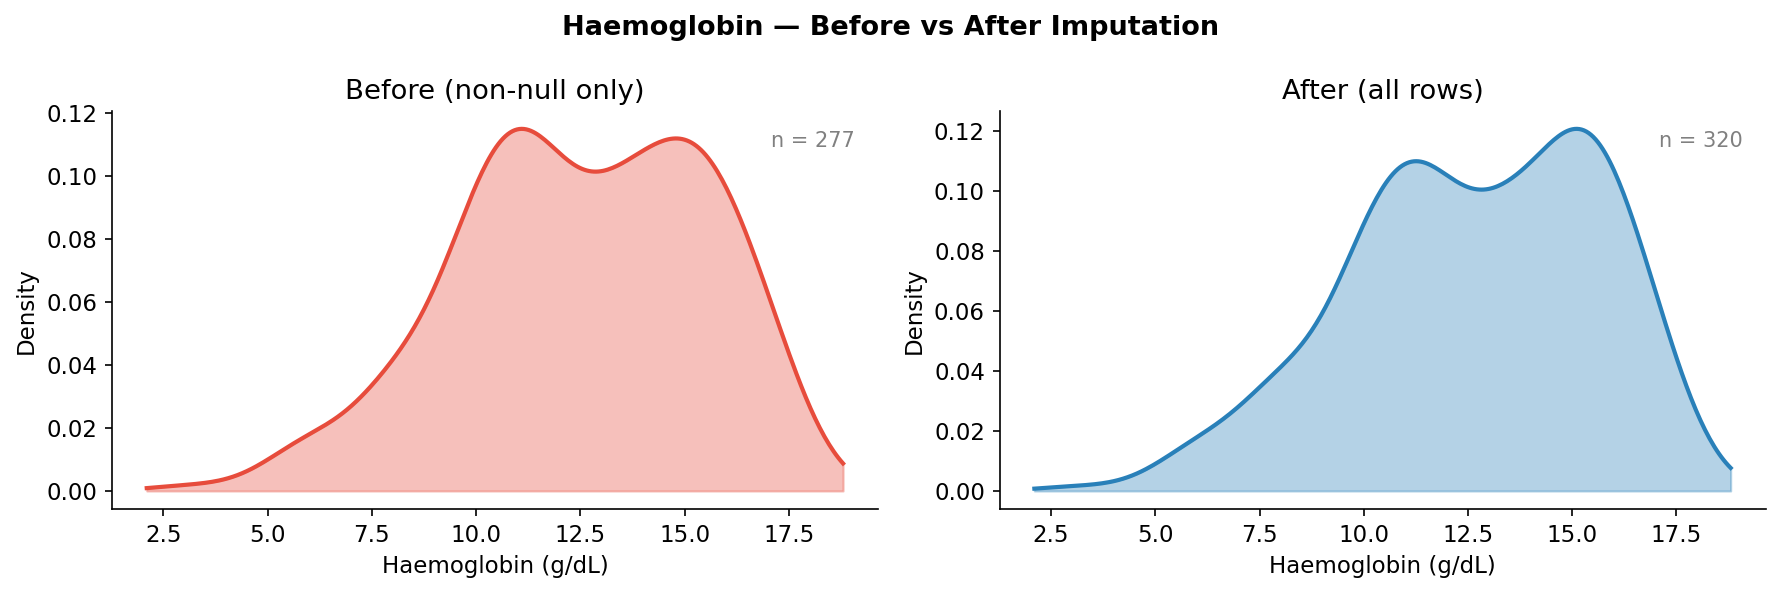

Saved - C:\Users\HP\Desktop\ml-kidney\visualizations\08_imputation_check.png


In [10]:
# Visualise: haemoglobin distribution before vs after imputation
hemo_after = X_train["haemoglobin"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Haemoglobin — Before vs After Imputation", fontsize=13, fontweight="bold")

for ax, data, label, color in zip(
    axes,
    [hemo_before, hemo_after],
    ["Before (non-null only)", "After (all rows)"],
    [COLOR_CKD, COLOR_NOTCKD],
):
    kde = gaussian_kde(data)
    x = np.linspace(data.min() - 1, data.max() + 1, 300)
    ax.fill_between(x, kde(x), alpha=0.35, color=color)
    ax.plot(x, kde(x), color=color, linewidth=2)
    ax.set_title(label)
    ax.set_xlabel("Haemoglobin (g/dL)")
    ax.set_ylabel("Density")
    ax.text(0.97, 0.95, f"n = {len(data)}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10, color="grey")

plt.tight_layout()
save_path = VIZ_DIR / "08_imputation_check.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved - {save_path}")

## 7 - Encode Categorical Features

We use `LabelEncoder` — one per column.  
> **Common bug:** using one shared encoder for all columns — it only remembers the last column's mapping.  
> **Fix:** a separate `LabelEncoder` instance for each column, stored in a dict.

In [11]:
cat_cols_present = [c for c in CATEGORICAL_COLS if c in X_train.columns]

print("Categorical columns BEFORE encoding:")
for col in cat_cols_present:
    print(f"  {col:30s} - {X_train[col].unique()}")

Categorical columns BEFORE encoding:
  red_blood_cells                - ['normal' 'abnormal']
  pus_cell                       - ['abnormal' 'normal']
  pus_cell_clumps                - ['notpresent' 'present']
  bacteria                       - ['notpresent' 'present']
  hypertension                   - ['no' 'yes']
  diabetes_mellitus              - ['no' 'yes']
  coronary_artery_disease        - ['no' 'yes']
  appetite                       - ['good' 'poor']
  pedal_edema                    - ['no' 'yes']
  anemia                         - ['no' 'yes']


In [12]:
X_train, X_test, encoders = encode_categoricals(X_train, X_test, fit=True)

print("Categorical columns AFTER encoding:")
for col in cat_cols_present:
    classes = encoders[col].classes_
    encoded = list(range(len(classes)))
    mapping = dict(zip(classes, encoded))
    print(f"  {col:30s} - {mapping}")

print(f"\n{len(encoders)} encoders fitted and stored in dict")

Categorical columns AFTER encoding:
  red_blood_cells                - {'abnormal': 0, 'normal': 1}
  pus_cell                       - {'abnormal': 0, 'normal': 1}
  pus_cell_clumps                - {'notpresent': 0, 'present': 1}
  bacteria                       - {'notpresent': 0, 'present': 1}
  hypertension                   - {'no': 0, 'yes': 1}
  diabetes_mellitus              - {'no': 0, 'yes': 1}
  coronary_artery_disease        - {'no': 0, 'yes': 1}
  appetite                       - {'good': 0, 'poor': 1}
  pedal_edema                    - {'no': 0, 'yes': 1}
  anemia                         - {'no': 0, 'yes': 1}

10 encoders fitted and stored in dict


In [13]:
# Save encoders so the API can load them at inference time
with open(ENCODER_PATH, "wb") as f:
    pickle.dump(encoders, f)

print(f"Encoders saved - {ENCODER_PATH}")

Encoders saved - C:\Users\HP\Desktop\ml-kidney\model\label_encoders.pkl


## 8 - Feature Scaling

We use `StandardScaler` (mean=0, std=1).  

**Why it matters:**
- `white_blood_cell_count` ranges 0–7800; `specific_gravity` ranges 1.005–1.025
- Without scaling, KNN distance is completely dominated by large-magnitude columns
- SVM's RBF kernel has the same problem

> **Fit on training data only.** Applying `fit_transform` to the test set would leak 
> test statistics into the scaler.

In [14]:
# Snapshot distributions BEFORE scaling for 3 representative columns
scale_demo_cols = ["age", "haemoglobin", "serum_creatinine"]
before_vals = {col: X_train[col].values for col in scale_demo_cols}

In [15]:
X_train_sc, X_test_sc, scaler = scale_features(X_train, X_test, fit=True)

print(f"X_train_sc shape : {X_train_sc.shape}  dtype: {X_train_sc.dtype}")
print(f"X_test_sc  shape : {X_test_sc.shape}   dtype: {X_test_sc.dtype}")
print(f"\nPost-scaling stats (should be ~mean=0, std=1):")
print(f"  mean : {X_train_sc.mean(axis=0)[:5].round(6)}  ...")
print(f"  std  : {X_train_sc.std(axis=0)[:5].round(6)}  ...")

X_train_sc shape : (320, 24)  dtype: float64
X_test_sc  shape : (80, 24)   dtype: float64

Post-scaling stats (should be ~mean=0, std=1):
  mean : [-0. -0. -0. -0.  0.]  ...
  std  : [1. 1. 1. 1. 1.]  ...


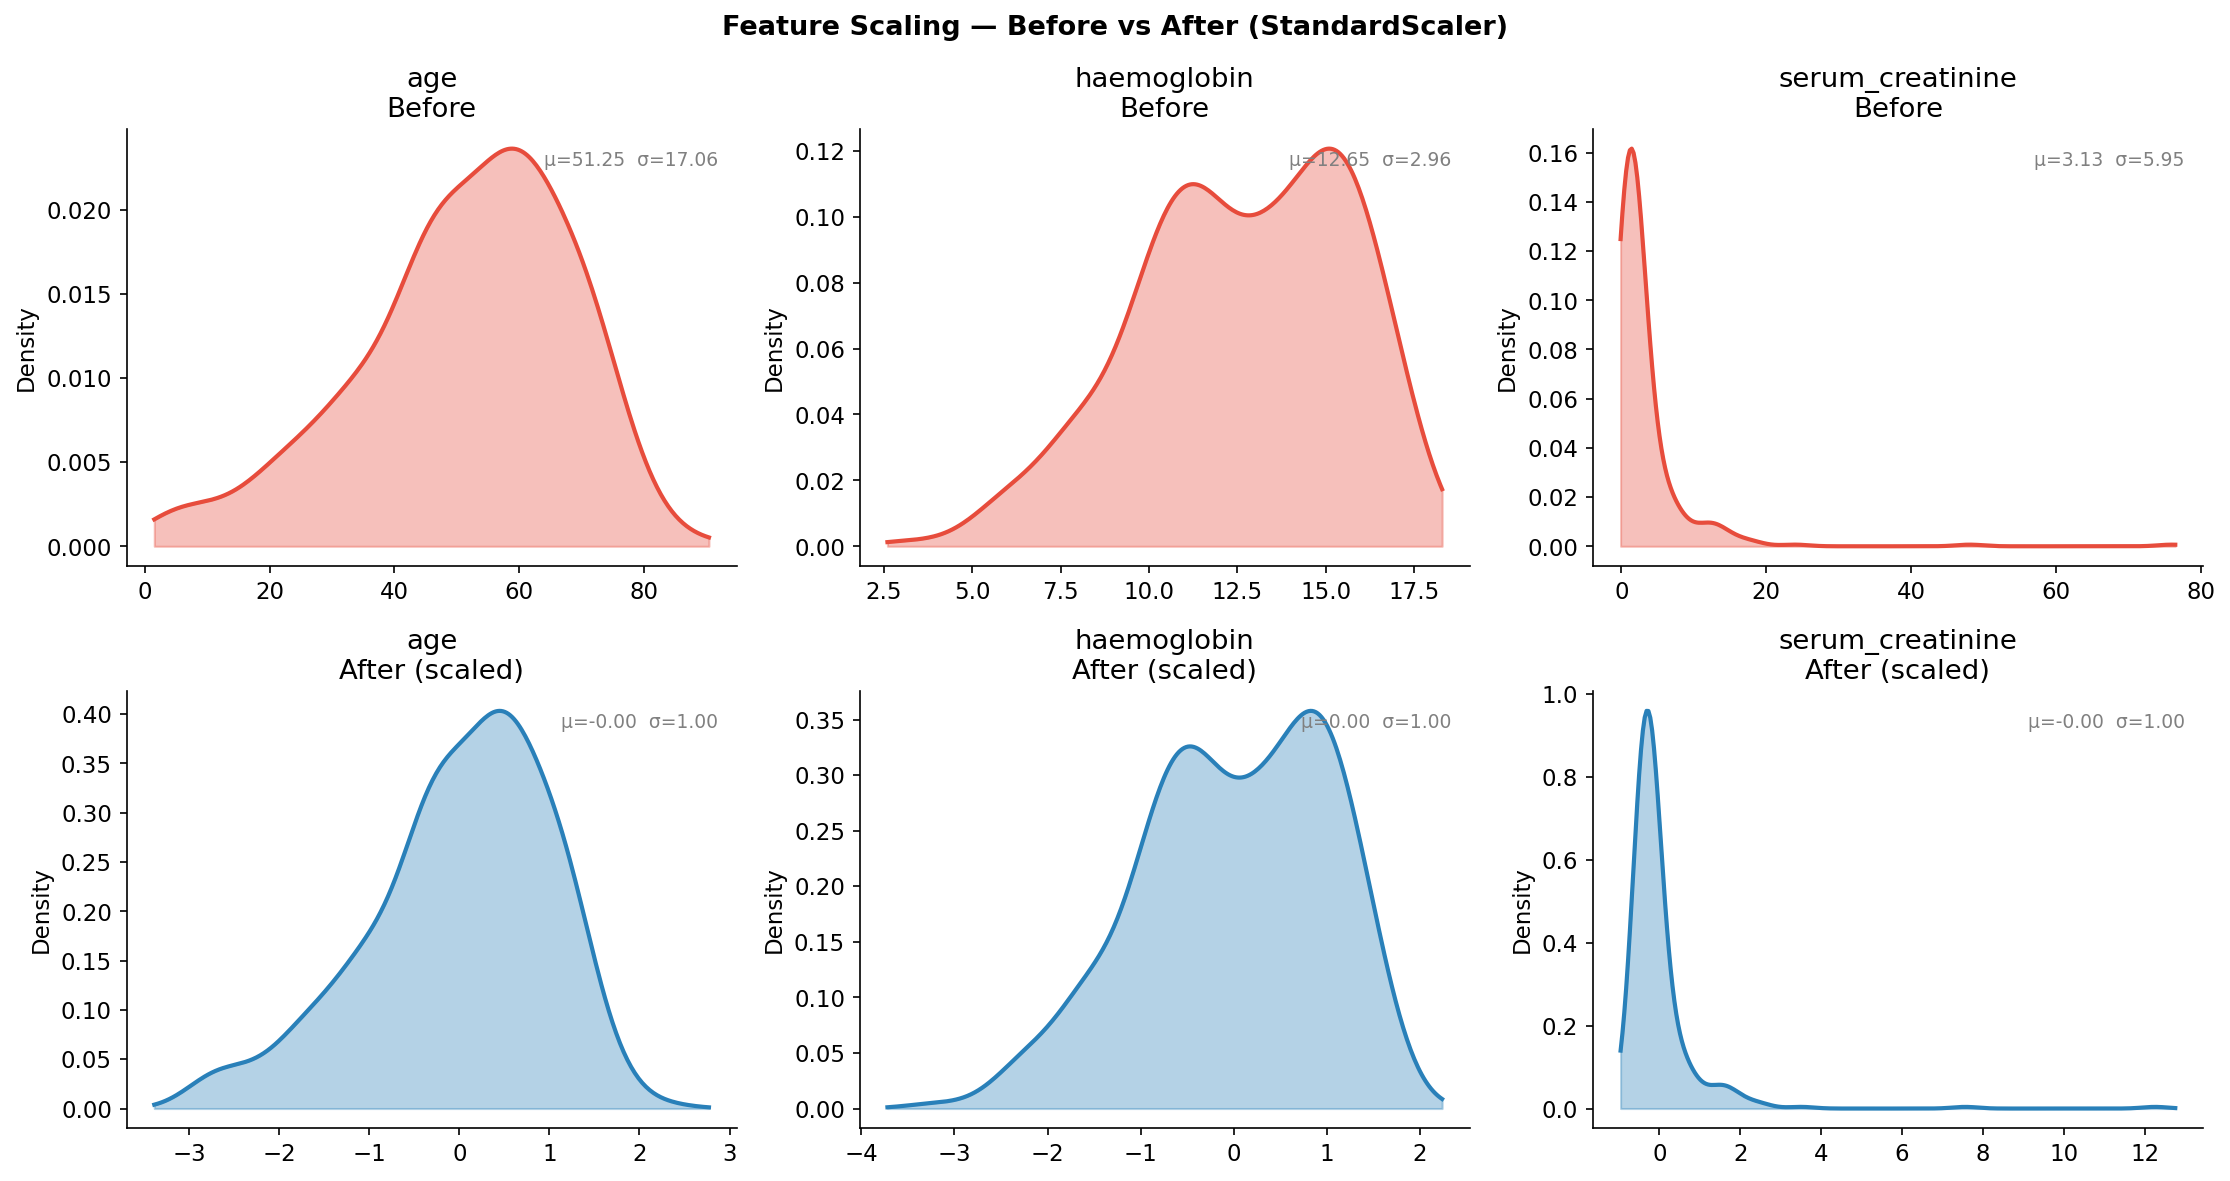

Saved - C:\Users\HP\Desktop\ml-kidney\visualizations\09_scaling_effect.png


In [16]:
# Visualise: Before vs After Scaling
feature_names = list(X_train.columns)
col_indices   = [feature_names.index(c) for c in scale_demo_cols]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Feature Scaling — Before vs After (StandardScaler)",
             fontsize=13, fontweight="bold")

for j, (col, idx) in enumerate(zip(scale_demo_cols, col_indices)):
    before = before_vals[col]
    after  = X_train_sc[:, idx]

    for row, (data, label, color) in enumerate([
        (before, f"{col}\nBefore", COLOR_CKD),
        (after,  f"{col}\nAfter (scaled)", COLOR_NOTCKD),
    ]):
        ax = axes[row, j]
        kde = gaussian_kde(data)
        x   = np.linspace(data.min() - 0.5, data.max() + 0.5, 300)
        ax.fill_between(x, kde(x), alpha=0.35, color=color)
        ax.plot(x, kde(x), color=color, linewidth=2)
        ax.set_title(label)
        ax.set_ylabel("Density")
        m = data.mean()
        s = data.std()
        ax.text(0.97, 0.95, f"μ={m:.2f}  σ={s:.2f}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=9, color="grey")

plt.tight_layout()
save_path = VIZ_DIR / "09_scaling_effect.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved - {save_path}")

In [17]:
# Save scaler
with open(SCALER_PATH, "wb") as f:
    pickle.dump(scaler, f)

print(f"Scaler saved - {SCALER_PATH}")

Scaler saved - C:\Users\HP\Desktop\ml-kidney\model\scaler.pkl


## 9 - Save Preprocessed Arrays

Save everything the modelling notebook needs as `.npy` files.  
Also save `feature_names.json` so the API knows column order at inference time.

In [18]:
# Save numpy arrays
np.save(MODEL_DIR / "X_train_sc.npy", X_train_sc)
np.save(MODEL_DIR / "X_test_sc.npy",  X_test_sc)
np.save(MODEL_DIR / "y_train.npy",    y_train.values)
np.save(MODEL_DIR / "y_test.npy",     y_test.values)

# Save feature names (column order must match at inference time)
with open(FEATURE_PATH, "w") as f:
    json.dump(feature_names, f, indent=2)

print("Saved artefacts:")
for p in sorted(MODEL_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:30s}  {size_kb:.1f} KB")

Saved artefacts:
  feature_names.json              0.5 KB
  kidney.pkl                      3.6 KB
  label_encoders.pkl              1.0 KB
  scaler.pkl                      1.5 KB
  X_test_sc.npy                   15.1 KB
  X_train_sc.npy                  60.1 KB
  y_test.npy                      0.8 KB
  y_train.npy                     2.6 KB


## 10 - End-to-End Pipeline Check

Run `run_full_pipeline()` and confirm its output matches everything we computed step-by-step above.

In [19]:
result = run_full_pipeline(save_artefacts=True)

print("Pipeline output keys:")
for k, v in result.items():
    shape = getattr(v, "shape", len(v) if hasattr(v, "__len__") else "—")
    print(f"  {k:20s} - {shape}")

# Sanity check: arrays should match what we computed manually
assert result["X_train_sc"].shape == X_train_sc.shape, "Shape mismatch!"
print("\nPipeline output matches manual steps")

Pipeline output keys:
  df                   - (400, 25)
  X_train              - (320, 24)
  X_test               - (80, 24)
  y_train              - (320,)
  y_test               - (80,)
  X_train_sc           - (320, 24)
  X_test_sc            - (80, 24)
  scaler               - —
  encoders             - 10
  feature_names        - 24

Pipeline output matches manual steps


## 11 - Summary

| Step | Action | Result |
|------|--------|--------|
| 1 | Load raw data | 400 rows × 25 features |
| 2 | Coerce types | 3 columns fixed (object → float64) |
| 3 | Clean dirty values | Tab chars removed; target encoded CKD=1, Not CKD=0 |
| 4 | Train/test split | 320 train / 80 test, stratified |
| 5 | Impute missing | Random-sample (numerical) + mode (categorical) — 0 NaN remaining |
| 6 | Encode categoricals | 10 LabelEncoders (one per column) → saved to `model/` |
| 7 | Scale features | StandardScaler → mean≈0, std≈1 → saved to `model/` |
| 8 | Save arrays | X_train_sc, X_test_sc, y_train, y_test, feature_names.json |